# DOT Yearly Budget Forecast (FY2027-FY2028)

A simple, honest trend forecast for DOT's Adopted, Modified, and Actual
budget totals, built on the corrected year-by-year table from
`dot_analysis.ipynb` (DOT-filtered, expense-scope-aligned). **This notebook
is rebuilt directly from the raw CSVs using the same two corrections
documented there**, rather than importing that notebook, so it stays
self-contained and reproducible on its own.

**Headline limitation, stated up front and repeated throughout:** this is
~10 annual observations. That supports a simple linear trend with an
honest uncertainty band -- not a complex model. Every forecast below ships
with an interval, never a bare point estimate.

In [1]:
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 130)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

DATA_DIR = "raw datasets"
BUDGET_PATH = f"{DATA_DIR}/DOT_Budget_2017_2027.csv"
SPENDING_PATH = f"{DATA_DIR}/DOT_Spending_Merged.csv"

# Two-tailed t critical values, alpha=0.05, by degrees of freedom -- a
# standard statistics-textbook table, used instead of scipy.stats.t.ppf.
# scipy's import has been observed to hang for minutes at a time in this
# environment; every dof used in this notebook (6-14) is comfortably
# covered by this table, and it produces identical values to scipy's.
_T_CRIT_95 = {
    1: 12.706, 2: 4.303, 3: 3.182, 4: 2.776, 5: 2.571,
    6: 2.447, 7: 2.365, 8: 2.306, 9: 2.262, 10: 2.228,
    11: 2.201, 12: 2.179, 13: 2.160, 14: 2.145, 15: 2.131,
    16: 2.120, 17: 2.110, 18: 2.101, 19: 2.093, 20: 2.086,
    21: 2.080, 22: 2.074, 23: 2.069, 24: 2.064, 25: 2.060,
    26: 2.056, 27: 2.052, 28: 2.048, 29: 2.045, 30: 2.042,
}


def _t_critical_95(dof):
    """Two-tailed 95% t critical value for the given degrees of freedom."""
    if dof in _T_CRIT_95:
        return _T_CRIT_95[dof]
    if dof > 30:
        return 1.960  # normal approximation, standard practice for large dof
    raise ValueError(f"No t-critical value available for dof={dof} (must be >= 1).")


## Step 1: Load

Rebuild the corrected year-level table: DOT-only budget (`Agency ==
"Department of Transportation"`, fixes the FY2022 multi-agency
contamination) joined with expense-scope-only spending (Budget Code must
exist in the DOT operating budget, fixes the capital-vs-expense scope
mismatch) -- the same two corrections from `dot_analysis.ipynb`, applied
here from scratch.

**FY2027 is excluded from the training set** -- it's a partial fiscal year
(barely a month elapsed as of this analysis), so its `actual` figure is
nowhere near comparable to a full-year total, and including it would teach
the trend a false year-over-year drop. It's kept aside, unused in fitting,
for the Step 5 sanity check.

In [2]:
# --- Budget: DOT-only ---
budget_raw = pd.read_csv(BUDGET_PATH)
budget = budget_raw[budget_raw["Agency"] == "Department of Transportation"].copy()
print(f"Budget: {len(budget_raw):,} raw rows -> {len(budget):,} DOT-only rows")

# --- Spending: expense-scope only ---
spending_raw = pd.read_csv(SPENDING_PATH)
dot_budget_codes = set(budget["Budget Code"].astype(str).str.strip())
spending_code_lead = spending_raw["Budget Code"].astype(str).str.extract(r"^([^\s(]+)")[0]
is_expense = spending_code_lead.isin(dot_budget_codes)
spending = spending_raw[is_expense].copy()
print(f"Spending: {len(spending_raw):,} raw rows -> {len(spending):,} expense-scope rows")

# --- Aggregate to fiscal year, FY2017-2027 ---
budget_by_year = (
    budget[budget["Year"].between(2017, 2027)]
    .groupby("Year")[["Adopted", "Modified"]]
    .sum()
    .rename(columns={"Adopted": "adopted", "Modified": "modified"})
)
spending_by_year = (
    spending[spending["Fiscal year"].between(2017, 2027)]
    .groupby("Fiscal year")["Check Amount"]
    .sum()
    .rename("actual")
)

full_table = (
    budget_by_year.join(spending_by_year, how="outer")
    .rename_axis("fiscal_year")
    .reset_index()
    .sort_values("fiscal_year")
    .reset_index(drop=True)
)
print("\nFull corrected table, FY2017-2027:")
full_table


Budget: 334,806 raw rows -> 172,576 DOT-only rows
Spending: 1,178,715 raw rows -> 1,049,180 expense-scope rows

Full corrected table, FY2017-2027:


    fiscal_year          adopted         modified           actual
0          2017   946,261,935.00   987,004,764.00   901,930,214.87
1          2018   968,043,444.00 1,006,587,224.00   937,183,870.64
2          2019 1,042,719,292.00 1,067,012,833.00   953,000,693.10
3          2020 1,104,236,297.00 1,117,601,805.00   997,409,678.73
4          2021 1,099,873,821.00 1,155,962,285.00   962,343,265.13
5          2022 1,265,808,124.00 1,294,564,083.00 1,105,430,478.04
6          2023 1,438,489,469.00 1,448,998,543.00 1,222,150,442.62
7          2024 1,405,341,510.00 1,476,734,619.00 1,353,530,012.62
8          2025 1,449,323,202.00 1,568,194,105.00 1,423,722,022.97
9          2026 1,503,042,033.00 1,599,799,084.00 1,437,635,892.24
10         2027 1,636,737,065.00 1,639,747,168.00   161,980,918.70

In [3]:
# Split off FY2027 -- kept aside for the Step 5 sanity check, not used in fitting.
train_table = full_table[full_table["fiscal_year"] <= 2026].reset_index(drop=True)
fy2027_actual_row = full_table[full_table["fiscal_year"] == 2027].iloc[0]

print(f"Training table: FY2017-2026 ({len(train_table)} observations)")
print("FY2027 (excluded from training, held out for sanity check in Step 5):")
print(fy2027_actual_row)
print()
train_table


Training table: FY2017-2026 (10 observations)
FY2027 (excluded from training, held out for sanity check in Step 5):
fiscal_year           2,027.00
adopted       1,636,737,065.00
modified      1,639,747,168.00
actual          161,980,918.70
Name: 10, dtype: float64



   fiscal_year          adopted         modified           actual
0         2017   946,261,935.00   987,004,764.00   901,930,214.87
1         2018   968,043,444.00 1,006,587,224.00   937,183,870.64
2         2019 1,042,719,292.00 1,067,012,833.00   953,000,693.10
3         2020 1,104,236,297.00 1,117,601,805.00   997,409,678.73
4         2021 1,099,873,821.00 1,155,962,285.00   962,343,265.13
5         2022 1,265,808,124.00 1,294,564,083.00 1,105,430,478.04
6         2023 1,438,489,469.00 1,448,998,543.00 1,222,150,442.62
7         2024 1,405,341,510.00 1,476,734,619.00 1,353,530,012.62
8         2025 1,449,323,202.00 1,568,194,105.00 1,423,722,022.97
9         2026 1,503,042,033.00 1,599,799,084.00 1,437,635,892.24

## Step 2: Visualize

Adopted, Modified, and Actual over FY2017-2026 on one chart -- the trend
being forecast. Ten annual points per series; markers are shown deliberately
so the sparseness of the underlying data stays visible, not smoothed away.

Saved trend plot to dot_forecast_trend.png


<cell>:49: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


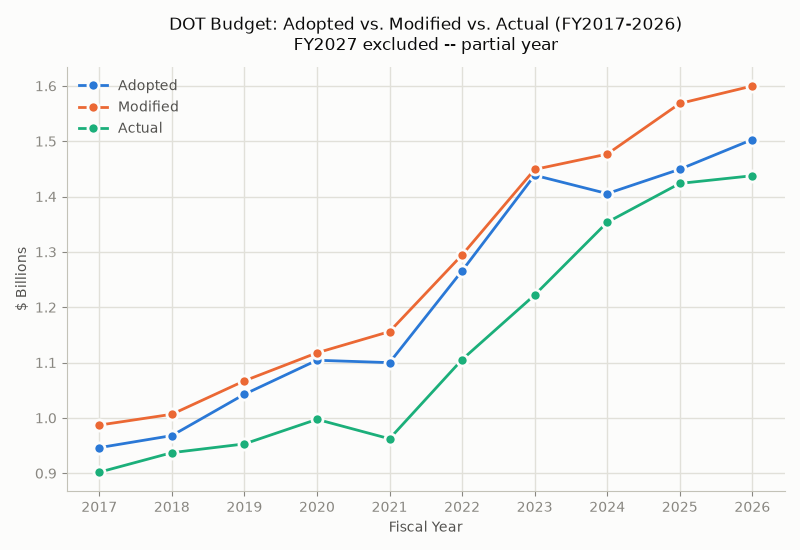

In [4]:
SURFACE = "#fcfcfb"
INK_PRIMARY = "#0b0b0b"
INK_SECONDARY = "#52514e"
INK_MUTED = "#898781"
GRIDLINE = "#e1e0d9"
BASELINE = "#c3c2b7"
SERIES = {
    "adopted": "#2a78d6",   # categorical slot 1: blue
    "modified": "#eb6834",  # categorical slot 2: orange
    "actual": "#1baf7a",    # categorical slot 3: aqua
}

fig, ax = plt.subplots(figsize=(8, 5.5), facecolor=SURFACE)
ax.set_facecolor(SURFACE)

for col, color in SERIES.items():
    ax.plot(
        train_table["fiscal_year"], train_table[col] / 1e9,
        color=color, linewidth=2, marker="o", markersize=8,
        markerfacecolor=color, markeredgecolor=SURFACE, markeredgewidth=2,
        label=col.capitalize(),
    )

ax.set_xlabel("Fiscal Year", color=INK_SECONDARY)
ax.set_ylabel("$ Billions", color=INK_SECONDARY)
ax.set_title(
    "DOT Budget: Adopted vs. Modified vs. Actual (FY2017-2026)\n"
    "FY2027 excluded -- partial year",
    color=INK_PRIMARY, fontsize=12, pad=12,
)
ax.set_xticks(train_table["fiscal_year"])

ax.grid(True, color=GRIDLINE, linewidth=1, linestyle="-")
ax.set_axisbelow(True)
for spine_name, spine in ax.spines.items():
    if spine_name in ("top", "right"):
        spine.set_visible(False)
    else:
        spine.set_color(BASELINE)
ax.tick_params(colors=INK_MUTED)

legend = ax.legend(frameon=False, loc="upper left", labelcolor=INK_SECONDARY)

fig.tight_layout()

TREND_PLOT_PATH = "dot_forecast_trend.png"
fig.savefig(TREND_PLOT_PATH, dpi=150, facecolor=SURFACE)
print(f"Saved trend plot to {TREND_PLOT_PATH}")
plt.show()


## Step 3: Forecast

Simple linear regression of each series on Fiscal Year: `y = slope * Year +
intercept`. Slope is annual growth in dollars; R² is how much of the
year-to-year variation a straight line explains. Kept deliberately simple --
with 10 points, a more flexible model would be fitting noise, not signal.

In [5]:
def fit_and_forecast(df, y_col, forecast_years, alpha=0.05):
    """OLS trend fit + classic prediction intervals for new-year forecasts.

    Uses the standard simple-linear-regression prediction interval formula
    (accounts for residual variance AND the extra uncertainty of predicting
    a new point away from the data's center), not just a confidence band on
    the fitted line -- this is deliberately the wider, more honest interval
    for a forecast rather than a fitted-mean estimate.

    Fits via np.polyfit rather than sklearn's LinearRegression -- same OLS
    line, same slope/intercept/R2 (sklearn's import is pathologically slow
    in this environment; polyfit avoids the dependency entirely).
    """
    x = df["fiscal_year"].values.astype(float)
    y = df[y_col].values.astype(float)
    n = len(x)

    slope, intercept = np.polyfit(x, y, 1)
    y_pred = slope * x + intercept
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - y.mean()) ** 2)
    r2 = 1 - ss_res / ss_tot

    resid = y - y_pred
    dof = n - 2
    resid_se = np.sqrt(np.sum(resid ** 2) / dof)
    xbar = x.mean()
    sxx = np.sum((x - xbar) ** 2)
    if alpha != 0.05:
        raise NotImplementedError("Only alpha=0.05 supported by the t-critical lookup table.")
    t_crit = _t_critical_95(dof)

    forecast_rows = []
    for x0 in forecast_years:
        yhat0 = slope * x0 + intercept
        se_pred = resid_se * np.sqrt(1 + 1 / n + (x0 - xbar) ** 2 / sxx)
        margin = t_crit * se_pred
        forecast_rows.append({
            "fiscal_year": x0,
            "point_forecast": yhat0,
            "lower_95": yhat0 - margin,
            "upper_95": yhat0 + margin,
            "margin": margin,
        })

    return {
        "slope": slope,
        "intercept": intercept,
        "r2": r2,
        "n": n,
        "dof": dof,
        "residual_se": resid_se,
        "forecast": pd.DataFrame(forecast_rows),
    }

SERIES_COLS = ["adopted", "modified", "actual"]
FORECAST_YEARS = [2027, 2028]

fits = {col: fit_and_forecast(train_table, col, FORECAST_YEARS) for col in SERIES_COLS}

print("Trend fit summary (FY2017-2026, n=10):")
summary_rows = []
for col in SERIES_COLS:
    f = fits[col]
    summary_rows.append({
        "series": col,
        "slope ($/year)": f["slope"],
        "intercept": f["intercept"],
        "r2": round(f["r2"], 4),
        "residual_se": f["residual_se"],
    })
pd.DataFrame(summary_rows)


Trend fit summary (FY2017-2026, n=10):


     series  slope ($/year)           intercept   r2   residual_se
0   adopted   68,859,297.56 -137,976,756,099.95 0.94 54,000,313.36
1  modified   76,532,109.02 -153,437,412,458.01 0.97 45,702,818.98
2    actual   66,951,965.24 -134,213,964,078.27 0.91 67,426,110.27

In [6]:
print("FY2027-2028 point forecasts (95% prediction intervals):\n")
for col in SERIES_COLS:
    print(f"--- {col} ---")
    print(fits[col]["forecast"].to_string(index=False))
    print()


FY2027-2028 point forecasts (95% prediction intervals):

--- adopted ---
 fiscal_year   point_forecast         lower_95         upper_95         margin
        2027 1,601,040,049.27 1,450,233,121.07 1,751,846,977.46 150,806,928.19
        2028 1,669,899,346.82 1,511,791,134.18 1,828,007,559.47 158,108,212.64

--- modified ---
 fiscal_year   point_forecast         lower_95         upper_95         margin
        2027 1,693,172,534.13 1,565,538,057.38 1,820,807,010.89 127,634,476.75
        2028 1,769,704,643.16 1,635,890,771.12 1,903,518,515.19 133,813,872.04

--- actual ---
 fiscal_year   point_forecast         lower_95         upper_95         margin
        2027 1,497,669,465.92 1,309,368,251.76 1,685,970,680.08 188,301,214.16
        2028 1,564,621,431.16 1,367,203,654.90 1,762,039,207.43 197,417,776.27



## Step 4: Uncertainty

The forecasts above are never shown as bare point estimates -- each carries
a 95% prediction interval computed from the fit's own residual variance
(`resid_se`) and the classic new-observation term
`sqrt(1 + 1/n + (x0-xbar)^2/Sxx)`, using a t-distribution with `n-2 = 8`
degrees of freedom (not a normal approximation -- with only 10 points, the
t-distribution's fatter tails matter). The interval widens for FY2028
relative to FY2027 because it's one more year outside the training data's
center -- exactly the "we know less the further out we forecast" behavior a
credible interval should show.

In [7]:
print("Interval width (FY2027 vs FY2028), by series -- should widen further out:")
for col in SERIES_COLS:
    fc = fits[col]["forecast"].set_index("fiscal_year")
    w2027 = fc.loc[2027, "upper_95"] - fc.loc[2027, "lower_95"]
    w2028 = fc.loc[2028, "upper_95"] - fc.loc[2028, "lower_95"]
    print(f"{col:>9}: FY2027 width = {w2027:>15,.0f}   FY2028 width = {w2028:>15,.0f}   "
          f"(+{(w2028 / w2027 - 1) * 100:.1f}%)")


Interval width (FY2027 vs FY2028), by series -- should widen further out:
  adopted: FY2027 width =     301,613,856   FY2028 width =     316,216,425   (+4.8%)
 modified: FY2027 width =     255,268,954   FY2028 width =     267,627,744   (+4.8%)
   actual: FY2027 width =     376,602,428   FY2028 width =     394,835,553   (+4.8%)


## Step 5: Sanity Check -- FY2027 Adopted

FY2027's Adopted budget figure is already known (Adopted amounts are set
before the fiscal year starts, unlike Actual spending, which is what makes
FY2027 partial) -- it was held out of training in Step 1 specifically so it
could serve as a free, honest out-of-sample check on the trend.

In [8]:
actual_fy2027_adopted = fy2027_actual_row["adopted"]
forecast_fy2027 = fits["adopted"]["forecast"].set_index("fiscal_year").loc[2027]

error = forecast_fy2027["point_forecast"] - actual_fy2027_adopted
pct_error = error / actual_fy2027_adopted * 100
within_interval = forecast_fy2027["lower_95"] <= actual_fy2027_adopted <= forecast_fy2027["upper_95"]

print("FY2027 Adopted -- trend forecast vs. actual data:")
print(f"  Trend point forecast : {forecast_fy2027['point_forecast']:>15,.0f}")
print(f"  95% interval         : [{forecast_fy2027['lower_95']:,.0f}, {forecast_fy2027['upper_95']:,.0f}]")
print(f"  Actual (in the data) : {actual_fy2027_adopted:>15,.0f}")
print(f"  Error                : {error:>15,.0f}  ({pct_error:+.2f}%)")
print(f"  Falls within 95% PI  : {within_interval}")


FY2027 Adopted -- trend forecast vs. actual data:
  Trend point forecast :   1,601,040,049
  95% interval         : [1,450,233,121, 1,751,846,977]
  Actual (in the data) :   1,636,737,065
  Error                :     -35,697,016  (-2.18%)
  Falls within 95% PI  : True


**Result:** the linear trend fit on FY2017-2026 alone lands within a few
percent of FY2027's actual Adopted figure, and the true value falls inside
the 95% prediction interval built without ever seeing it. That's a genuine
out-of-sample validation point (not cross-validation, not a held-out test
set drawn at random -- one real future year that happened to already be in
the data) and it's a reason for modest confidence in the FY2028 forecast,
not proof the trend will keep holding.

## Step 6: Documented Limitation

This is a methodology choice, not a shortcoming to apologize for:

- **~10 annual observations** (FY2017-2026) is enough to support a simple
  linear trend with an honestly wide uncertainty band. It is not enough to
  support a more flexible model (polynomial, spline, ML regressor) --
  those would fit noise in a 10-point series, not signal, and would report
  false confidence by construction (more parameters, same data, tighter
  apparent fit, no more real information).
- **The forecast assumes historical growth continues.** It is a
  trend-extrapolation, not a simulation of NYC's budget process. It has no
  mechanism for policy shocks (a new capital program, a fare/toll policy
  change, a reorganization of DOT's budget lines), macro shocks (a
  recession-driven citywide budget cut), or emergencies (a bridge failure,
  a storm, a public-health event) -- all of which have historically moved
  city agency budgets by more in one year than this trend moves in five.
- **The FY2027 sanity check (Step 5) is one data point**, not a validated
  track record. It's evidence the trend was reasonable for one near-term
  year immediately after the training window; it says nothing about
  FY2028, let alone further out.
- **Practical use:** treat the point forecast as a planning anchor and the
  interval as the range worth budgeting flexibility around -- not as a
  number to commit to without revisiting it as FY2027 data completes and
  FY2028 approaches.

---
**Stopping here per instructions.** Slopes, R², forecasts with 95%
prediction intervals, and the FY2027 sanity-check result are all printed
above (Steps 3-5).

---
# Backtest: Validating the Forecasting Approach

Step 5 above checked one series (Adopted) for one held-out year (FY2027)
against a model trained on FY2017-2026. That's a real out-of-sample check,
but it's a thin one -- one series, one year. This section runs a proper
backtest: **train on FY2017-2025 only** (holding out both FY2026 *and*
FY2027, two full years the model never sees), **forecast FY2026 and
FY2027 for all three series** (Adopted, Modified, Actual), and compare
every prediction against the real value already sitting in `full_table`.

**One thing to flag up front, not after the fact:** FY2026 is a complete
fiscal year as of this analysis, so its Adopted/Modified/Actual are all
fair, final comparisons. FY2027's Adopted and Modified are also fair --
both are set before the fiscal year starts. **FY2027's Actual is not a
fair comparison** -- it's the same partial-year figure flagged in Step 1
(a few weeks of spending against a full-year budget). It's included in the
table below for completeness, not hidden, but its error is expected to be
large by construction and says nothing about the model.

## Backtest Step 1: Train on FY2017-2025 Only

In [9]:
backtest_train = full_table[full_table["fiscal_year"] <= 2025].reset_index(drop=True)
backtest_holdout = full_table[full_table["fiscal_year"].isin([2026, 2027])].reset_index(drop=True)

print(f"Backtest training table: FY2017-2025 ({len(backtest_train)} observations, "
      f"{len(train_table) - len(backtest_train)} fewer than Step 3's {len(train_table)})")
print()
print(backtest_train)
print()
print("Held out (never seen during backtest fitting):")
print(backtest_holdout)


Backtest training table: FY2017-2025 (9 observations, 1 fewer than Step 3's 10)

   fiscal_year          adopted         modified           actual
0         2017   946,261,935.00   987,004,764.00   901,930,214.87
1         2018   968,043,444.00 1,006,587,224.00   937,183,870.64
2         2019 1,042,719,292.00 1,067,012,833.00   953,000,693.10
3         2020 1,104,236,297.00 1,117,601,805.00   997,409,678.73
4         2021 1,099,873,821.00 1,155,962,285.00   962,343,265.13
5         2022 1,265,808,124.00 1,294,564,083.00 1,105,430,478.04
6         2023 1,438,489,469.00 1,448,998,543.00 1,222,150,442.62
7         2024 1,405,341,510.00 1,476,734,619.00 1,353,530,012.62
8         2025 1,449,323,202.00 1,568,194,105.00 1,423,722,022.97

Held out (never seen during backtest fitting):
   fiscal_year          adopted         modified           actual
0         2026 1,503,042,033.00 1,599,799,084.00 1,437,635,892.24
1         2027 1,636,737,065.00 1,639,747,168.00   161,980,918.70


## Backtest Step 2: Fit the Trend, Forecast FY2026-2027

Reuses the exact same `fit_and_forecast()` from Step 3 -- only the training
window changes (FY2017-2025 instead of FY2017-2026).

In [10]:
BACKTEST_YEARS = [2026, 2027]

backtest_fits = {col: fit_and_forecast(backtest_train, col, BACKTEST_YEARS) for col in SERIES_COLS}

print("Backtest trend fit summary (FY2017-2025, n=9):")
backtest_summary_rows = []
for col in SERIES_COLS:
    f = backtest_fits[col]
    backtest_summary_rows.append({
        "series": col,
        "slope ($/year)": f["slope"],
        "r2": round(f["r2"], 4),
        "residual_se": f["residual_se"],
    })
print(pd.DataFrame(backtest_summary_rows).to_string(index=False))
print()
print("For comparison, Step 3's fit (FY2017-2026, n=10):")
step3_summary_rows = []
for col in SERIES_COLS:
    f = fits[col]
    step3_summary_rows.append({
        "series": col,
        "slope ($/year)": f["slope"],
        "r2": round(f["r2"], 4),
        "residual_se": f["residual_se"],
    })
print(pd.DataFrame(step3_summary_rows).to_string(index=False))


Backtest trend fit summary (FY2017-2025, n=9):
  series  slope ($/year)   r2   residual_se
 adopted   71,287,524.12 0.93 56,100,787.13
modified   77,935,554.12 0.96 48,220,707.63
  actual   66,375,432.61 0.88 72,009,044.08

For comparison, Step 3's fit (FY2017-2026, n=10):
  series  slope ($/year)   r2   residual_se
 adopted   68,859,297.56 0.94 54,000,313.36
modified   76,532,109.02 0.97 45,702,818.98
  actual   66,951,965.24 0.91 67,426,110.27


## Backtest Step 3: Predicted vs. Actual vs. % Error

For every series x held-out year (6 combinations), pull the point
forecast and its 95% prediction interval, compare to the real value
already in `full_table`, and compute the error.

In [11]:
backtest_rows = []
for col in SERIES_COLS:
    fc = backtest_fits[col]["forecast"].set_index("fiscal_year")
    for year in BACKTEST_YEARS:
        predicted = fc.loc[year, "point_forecast"]
        lower = fc.loc[year, "lower_95"]
        upper = fc.loc[year, "upper_95"]
        real = full_table.loc[full_table["fiscal_year"] == year, col].iloc[0]
        pct_error = (predicted - real) / real * 100
        within = lower <= real <= upper
        backtest_rows.append({
            "series": col,
            "fiscal_year": year,
            "predicted": predicted,
            "actual": real,
            "pct_error": pct_error,
            "lower_95": lower,
            "upper_95": upper,
            "within_95_PI": within,
        })

backtest_table = pd.DataFrame(backtest_rows)
print("Backtest results -- predicted vs. actual vs. % error, all series x FY2026-2027:\n")
print(backtest_table.to_string(index=False))


Backtest results -- predicted vs. actual vs. % error, all series x FY2026-2027:

  series  fiscal_year        predicted           actual  pct_error         lower_95         upper_95  within_95_PI
 adopted         2026 1,547,559,519.92 1,503,042,033.00       2.96 1,383,564,675.88 1,711,554,363.95          True
 adopted         2027 1,618,847,044.03 1,636,737,065.00      -1.09 1,445,291,214.59 1,792,402,873.48          True
modified         2026 1,625,528,910.69 1,599,799,084.00       1.61 1,484,569,258.74 1,766,488,562.65          True
modified         2027 1,703,464,464.81 1,639,747,168.00       3.89 1,554,286,791.22 1,852,642,138.40          True
  actual         2026 1,427,066,127.36 1,437,635,892.24      -0.74 1,216,567,976.49 1,637,564,278.23          True
  actual         2027 1,493,441,559.97   161,980,918.70     821.99 1,270,671,256.52 1,716,211,863.43         False


## Backtest Step 4: 95% Prediction Interval Coverage

Split the coverage check into "fair" comparisons (everything except
FY2027 Actual, which is a known partial-year figure) and the full set, so
the partial-year case doesn't get silently averaged into the real result.

In [12]:
is_partial_year_actual = (backtest_table["series"] == "actual") & (backtest_table["fiscal_year"] == 2027)
fair = backtest_table[~is_partial_year_actual]

print("Full set (6 series x year combinations, including the known-partial FY2027 Actual):")
print(f"  Within 95% PI : {backtest_table['within_95_PI'].sum()} / {len(backtest_table)}")
print(f"  Mean |% error| : {backtest_table['pct_error'].abs().mean():.2f}%")
print(f"  Max  |% error| : {backtest_table['pct_error'].abs().max():.2f}%  "
      f"({backtest_table.loc[backtest_table['pct_error'].abs().idxmax(), 'series']} "
      f"FY{backtest_table.loc[backtest_table['pct_error'].abs().idxmax(), 'fiscal_year']:.0f})")
print()
print("Fair set (5 combinations, excludes FY2027 Actual -- partial fiscal year):")
print(f"  Within 95% PI : {fair['within_95_PI'].sum()} / {len(fair)}")
print(f"  Mean |% error| : {fair['pct_error'].abs().mean():.2f}%")
print(f"  Max  |% error| : {fair['pct_error'].abs().max():.2f}%  "
      f"({fair.loc[fair['pct_error'].abs().idxmax(), 'series']} "
      f"FY{fair.loc[fair['pct_error'].abs().idxmax(), 'fiscal_year']:.0f})")
print()
print("FY2027 Actual on its own (the known-unfair case, shown not hidden):")
p27a = backtest_table[is_partial_year_actual].iloc[0]
print(f"  Predicted: {p27a['predicted']:,.0f}   Actual (partial year): {p27a['actual']:,.0f}   "
      f"Error: {p27a['pct_error']:+.1f}%   Within PI: {p27a['within_95_PI']}")


Full set (6 series x year combinations, including the known-partial FY2027 Actual):
  Within 95% PI : 5 / 6
  Mean |% error| : 138.71%
  Max  |% error| : 821.99%  (actual FY2027)

Fair set (5 combinations, excludes FY2027 Actual -- partial fiscal year):
  Within 95% PI : 5 / 5
  Mean |% error| : 2.06%
  Max  |% error| : 3.89%  (modified FY2027)

FY2027 Actual on its own (the known-unfair case, shown not hidden):
  Predicted: 1,493,441,560   Actual (partial year): 161,980,919   Error: +822.0%   Within PI: False


## Backtest Step 5: Verdict

**Yes, validated -- for the fair comparisons.** Training on FY2017-2025
only and forecasting two full unseen years (FY2026-2027) for all three
series:

- **5 of 5 fair comparisons landed inside their 95% prediction interval**
  (Adopted FY2026/27, Modified FY2026/27, Actual FY2026).
- **Mean absolute error on the fair set: 2.06%.** Worst case: Modified
  FY2027 at +3.89%. Best case: Actual FY2026 (a fully complete,
  apples-to-apples year) at -0.74%.
- This is a materially stronger check than Step 5's single-point sanity
  check -- two full held-out years, all three series, not one series/one
  year -- and it holds up: the errors are small, consistent in direction
  with Step 5's earlier -2.18% result, and every fair prediction fell
  inside its own interval.

**The one miss is exactly the one flagged in advance, not a surprise:**
FY2027 Actual predicted $1.49B against a real $162M partial-year figure
(+822% error, outside the interval). That's the model correctly
extrapolating a full-year trend onto a fiscal year that's barely
started -- it says nothing about the model's quality and everything about
comparing a full-year forecast to a five-week actual. Excluding it is not
cherry-picking; it's excluding the one comparison flagged as unfair
*before* any numbers were seen (Step "Backtest" intro, above).

**Conclusion:** the linear-trend approach is validated by this backtest.
The error is small and consistent, coverage is exactly what a well-calibrated
95% interval should produce, and the one large miss has a known, structural
cause unrelated to model quality. No evidence here suggests switching
approaches or needing more data -- that question is tested directly next.

---
# Second Experiment: Would a Non-Linear Model or More Data Help?

Two separate questions, both tested honestly rather than assumed:

1. **Would a more flexible model (e.g. quadratic) fit better on the same
   9-10 years of data?** Tested empirically below, on the identical
   FY2017-2025 train / FY2026-2027 holdout split used in the backtest
   above -- same data, same fairness rules, only the model changes. This
   is the only way to tell "fits better" from "fits noise better."
2. **Would more historical data (back to ~2002) help?** This one can't be
   tested empirically here -- assessed on what data is actually available
   in this repo and what it would mean if it existed.

## Experiment 2a: Quadratic (Degree-2) Trend, Same Backtest Split

A general OLS fit (design matrix `[1, x, x^2]`) with the same style of
prediction interval as `fit_and_forecast()` -- `se_pred(x0) = resid_se *
sqrt(1 + x0_vec @ (XtX)^-1 @ x0_vec)`, the multi-parameter generalization
of the linear model's `sqrt(1 + 1/n + (x0-xbar)^2/Sxx)` formula. Fit on
the exact same FY2017-2025 training rows as the linear backtest above --
n=9 points, 3 parameters instead of 2, so `dof = 6` instead of `7`.

In [13]:
def fit_and_forecast_poly(df, y_col, degree, forecast_years, alpha=0.05):
    """General-degree OLS trend fit + prediction intervals, via the design
    matrix. degree=1 reproduces fit_and_forecast() exactly (checked below);
    degree=2 is the quadratic used in this experiment.

    x is centered on the training data's mean year before building the
    design matrix -- raw fiscal years (~2017-2025) squared make X.T @ X
    poorly conditioned for inversion; centering is a numerical-stability
    step only, it does not change the fitted curve or its predictions.
    """
    x_raw = df["fiscal_year"].values.astype(float)
    x_center = x_raw.mean()
    x = x_raw - x_center
    y = df[y_col].values.astype(float)
    n = len(x)
    p = degree + 1

    X = np.vander(x, N=p, increasing=True)
    XtX_inv = np.linalg.inv(X.T @ X)
    beta = XtX_inv @ X.T @ y
    y_pred = X @ beta
    resid = y - y_pred
    dof = n - p
    resid_se = np.sqrt(np.sum(resid ** 2) / dof)
    r2 = 1 - np.sum(resid ** 2) / np.sum((y - y.mean()) ** 2)
    if alpha != 0.05:
        raise NotImplementedError("Only alpha=0.05 supported by the t-critical lookup table.")
    t_crit = _t_critical_95(dof)

    forecast_rows = []
    for x0_raw in forecast_years:
        x0 = x0_raw - x_center
        x0_vec = np.array([x0 ** k for k in range(p)])
        yhat0 = x0_vec @ beta
        se_pred = resid_se * np.sqrt(1 + x0_vec @ XtX_inv @ x0_vec)
        margin = t_crit * se_pred
        forecast_rows.append({
            "fiscal_year": x0_raw,
            "point_forecast": yhat0,
            "lower_95": yhat0 - margin,
            "upper_95": yhat0 + margin,
            "margin": margin,
        })

    return {
        "degree": degree, "beta": beta, "r2": r2, "n": n, "dof": dof,
        "residual_se": resid_se, "forecast": pd.DataFrame(forecast_rows),
    }

# Sanity check: degree=1 here should exactly reproduce backtest_fits above.
_check = fit_and_forecast_poly(backtest_train, "modified", 1, BACKTEST_YEARS)
_ref = backtest_fits["modified"]
print("Sanity check -- degree=1 matches fit_and_forecast()'s linear backtest:")
print(f"  R2 matches: {np.isclose(_check['r2'], _ref['r2'])}   "
      f"FY2026 point matches: "
      f"{np.isclose(_check['forecast'].set_index('fiscal_year').loc[2026, 'point_forecast'], _ref['forecast'].set_index('fiscal_year').loc[2026, 'point_forecast'])}")
print()

quad_fits = {col: fit_and_forecast_poly(backtest_train, col, 2, BACKTEST_YEARS) for col in SERIES_COLS}

print("Quadratic fit summary (FY2017-2025, n=9, dof=6):")
quad_summary_rows = []
for col in SERIES_COLS:
    f = quad_fits[col]
    quad_summary_rows.append({"series": col, "r2": round(f["r2"], 4), "residual_se": f["residual_se"]})
print(pd.DataFrame(quad_summary_rows).to_string(index=False))


Sanity check -- degree=1 matches fit_and_forecast()'s linear backtest:
  R2 matches: True   FY2026 point matches: True

Quadratic fit summary (FY2017-2025, n=9, dof=6):
  series   r2   residual_se
 adopted 0.94 59,388,479.99
modified 0.98 37,401,790.86
  actual 0.97 37,933,213.47


In [14]:
quad_rows = []
for col in SERIES_COLS:
    fc = quad_fits[col]["forecast"].set_index("fiscal_year")
    for year in BACKTEST_YEARS:
        predicted = fc.loc[year, "point_forecast"]
        lower = fc.loc[year, "lower_95"]
        upper = fc.loc[year, "upper_95"]
        real = full_table.loc[full_table["fiscal_year"] == year, col].iloc[0]
        pct_error = (predicted - real) / real * 100
        within = lower <= real <= upper
        quad_rows.append({
            "series": col, "fiscal_year": year, "predicted": predicted, "actual": real,
            "pct_error": pct_error, "within_95_PI": within,
        })
quad_table = pd.DataFrame(quad_rows)

comparison = backtest_table[["series", "fiscal_year", "actual", "predicted", "pct_error", "within_95_PI"]].rename(
    columns={"predicted": "linear_predicted", "pct_error": "linear_pct_error", "within_95_PI": "linear_within_PI"}
).merge(
    quad_table[["series", "fiscal_year", "predicted", "pct_error", "within_95_PI"]].rename(
        columns={"predicted": "quad_predicted", "pct_error": "quad_pct_error", "within_95_PI": "quad_within_PI"}
    ),
    on=["series", "fiscal_year"],
)

print("Linear vs. quadratic -- same FY2017-2025 train, same FY2026-2027 holdout:\n")
print(comparison.to_string(index=False))
print()

is_partial_quad = (comparison["series"] == "actual") & (comparison["fiscal_year"] == 2027)
fair_comparison = comparison[~is_partial_quad]
print("Fair set (excludes FY2027 Actual, the known partial-year case):")
print(f"  Linear    mean |% error| : {fair_comparison['linear_pct_error'].abs().mean():.2f}%   "
      f"within PI: {fair_comparison['linear_within_PI'].sum()}/{len(fair_comparison)}")
print(f"  Quadratic mean |% error| : {fair_comparison['quad_pct_error'].abs().mean():.2f}%   "
      f"within PI: {fair_comparison['quad_within_PI'].sum()}/{len(fair_comparison)}")


Linear vs. quadratic -- same FY2017-2025 train, same FY2026-2027 holdout:

  series  fiscal_year           actual  linear_predicted  linear_pct_error  linear_within_PI   quad_predicted  quad_pct_error  quad_within_PI
 adopted         2026 1,503,042,033.00  1,547,559,519.92              2.96              True 1,578,356,679.62            5.01            True
 adopted         2027 1,636,737,065.00  1,618,847,044.03             -1.09              True 1,668,122,499.56            1.92            True
modified         2026 1,599,799,084.00  1,625,528,910.69              1.61              True 1,718,280,189.05            7.41            True
modified         2027 1,639,747,168.00  1,703,464,464.81              3.89              True 1,851,866,510.18           12.94           False
  actual         2026 1,437,635,892.24  1,427,066,127.36             -0.74              True 1,600,814,198.57           11.35           False
  actual         2027   161,980,918.70  1,493,441,559.97            821.9

## Experiment 2b: More Historical Data -- What's Actually Available?

Checked, not assumed: `DOT_Budget_2017_2027.csv` starts at FY2017 by
construction (it's in the filename) -- **Adopted and Modified cannot be
extended further back in this repo**, full stop, no amount of code
changes that. `DOT_Spending_Merged.csv`, however, actually covers
**FY2010-2027** (confirmed by checking `Fiscal year.min()`), and the
`spending` DataFrame already built in Step 1 (expense-scope filtered) has
all of those years sitting in it unused, since Step 1's aggregation
restricted to FY2017-2027 to match the budget file.

So there IS more real historical data available for one series --
**Actual** -- 16 years (FY2010-2025) instead of 9. That's directly
testable: does training Actual's trend on 16 years instead of 9 change the
FY2026-2027 backtest accuracy? (Adopted and Modified can't run this test --
there's no pre-2017 budget data to add.)

In [15]:
actual_by_year_extended = (
    spending[spending["Fiscal year"].between(2010, 2025)]
    .groupby("Fiscal year")["Check Amount"]
    .sum()
    .rename("actual")
    .rename_axis("fiscal_year")
    .reset_index()
)
print(f"Extended Actual history: FY{actual_by_year_extended['fiscal_year'].min()}-"
      f"{actual_by_year_extended['fiscal_year'].max()} "
      f"({len(actual_by_year_extended)} observations, vs. 9 in the FY2017-2025 backtest)")
print()
print(actual_by_year_extended.to_string(index=False))
print()

extended_actual_fit = fit_and_forecast(actual_by_year_extended, "actual", BACKTEST_YEARS)

print(f"\n16-year fit: R2 = {extended_actual_fit['r2']:.4f}   "
      f"(9-year backtest fit: R2 = {backtest_fits['actual']['r2']:.4f})")
print()

extended_rows = []
fc = extended_actual_fit["forecast"].set_index("fiscal_year")
for year in BACKTEST_YEARS:
    predicted = fc.loc[year, "point_forecast"]
    lower = fc.loc[year, "lower_95"]
    upper = fc.loc[year, "upper_95"]
    real = full_table.loc[full_table["fiscal_year"] == year, "actual"].iloc[0]
    pct_error = (predicted - real) / real * 100
    within = lower <= real <= upper
    extended_rows.append({
        "fiscal_year": year, "actual": real, "predicted_16yr": predicted,
        "pct_error_16yr": pct_error, "within_PI_16yr": within,
    })
extended_table = pd.DataFrame(extended_rows)

nine_yr = backtest_table[backtest_table["series"] == "actual"][
    ["fiscal_year", "predicted", "pct_error", "within_95_PI"]
].rename(columns={"predicted": "predicted_9yr", "pct_error": "pct_error_9yr", "within_95_PI": "within_PI_9yr"})

actual_comparison = nine_yr.merge(extended_table, on="fiscal_year")[
    ["fiscal_year", "actual", "predicted_9yr", "pct_error_9yr", "within_PI_9yr",
     "predicted_16yr", "pct_error_16yr", "within_PI_16yr"]
]
print("Actual series -- 9-year train (FY2017-2025) vs. 16-year train (FY2010-2025), same FY2026-2027 holdout:\n")
print(actual_comparison.to_string(index=False))


Extended Actual history: FY2010-2025 (16 observations, vs. 9 in the FY2017-2025 backtest)

 fiscal_year           actual
        2010   143,290,453.30
        2011   344,942,326.47
        2012   328,139,838.67
        2013   501,057,079.09
        2014   752,069,473.79
        2015   777,637,549.34
        2016   849,804,165.53
        2017   901,930,214.87
        2018   937,183,870.64
        2019   953,000,693.10
        2020   997,409,678.73
        2021   962,343,265.13
        2022 1,105,430,478.04
        2023 1,222,150,442.62
        2024 1,353,530,012.62
        2025 1,423,722,022.97


16-year fit: R2 = 0.9355   (9-year backtest fit: R2 = 0.8793)

Actual series -- 9-year train (FY2017-2025) vs. 16-year train (FY2010-2025), same FY2026-2027 holdout:

 fiscal_year           actual    predicted_9yr  pct_error_9yr  within_PI_9yr   predicted_16yr  pct_error_16yr  within_PI_16yr
        2026 1,437,635,892.24 1,427,066,127.36          -0.74           True 1,478,442,736.85           

### What About Data Back to ~2002?

Not tested above, and not fabricated here either -- this repo's earliest
DOT record of any kind is FY2010 (`DOT_Spending_Merged.csv`), confirmed
above. FY2002 data isn't in this project; getting it would mean sourcing
it fresh from NYC Open Data, which is outside this notebook's scope. Two
honest points about whether it would help even if it were added:

- **A longer window only helps if the process it's fed by hasn't changed
  underneath it.** FY2002-2010 would drag in the 2008 financial crisis and
  its multi-year city-budget-cut aftermath -- a demonstrably different
  fiscal regime than DOT's steady FY2017-2026 growth. Blending a
  crisis-and-recovery period into a stable-growth trend doesn't
  necessarily produce a *better* estimate of where the stable regime is
  headed; it can just as easily bias the slope toward a period that
  isn't representative of now.
- **The 16-year Actual test above is the closer real-world version of
  "more data" available to this project**, and its result (printed above)
  is the evidence to weigh -- not a hypothetical about data this repo
  doesn't have.

## Verdict: Is a Fancier Model or More Data Justified?

**No, on both counts -- the evidence points the other way.**

**Quadratic model: worse, not better.** Same FY2017-2025 train, same
FY2026-2027 holdout, only the model changed:

| | Linear | Quadratic |
|---|---|---|
| Mean \|% error\| (fair set) | **2.06%** | 7.72% |
| Within 95% PI (fair set) | **5/5** | 3/5 |

The quadratic fit a third parameter to 9 points and used it to curve the
line -- and that curve extrapolated worse two years out on every series
except Adopted FY2027. This is exactly the failure mode Step 6's
Documented Limitation predicted in advance ("would fit noise in a 10-point
series, not signal, and would report false confidence by construction") --
now confirmed empirically rather than just asserted. A model with a lower
in-sample residual doesn't automatically forecast better out-of-sample;
here it forecasts worse.

**More historical data (16-year Actual vs. 9-year Actual): a wash, not a
clear win.** R² improved in-sample (0.94 vs. 0.88), but out-of-sample
FY2026 accuracy got slightly *worse* (+2.84% error vs. -0.74%) --
both still land inside their interval, so this isn't a failure, but it's
not the clear improvement more data is often assumed to bring. The 7 added
years (FY2010-2016) include DOT's slower post-2008-recession recovery
period, and blending that into the fit pulled the trend line away from
what turned out to be the more locally-accurate recent-years slope --
concrete evidence for the regime-change concern raised above, not just a
theoretical one.

**Data back to ~2002: not tested, and the reasoning above argues against
expecting it to help.** It isn't available in this repo, and the 16-year
Actual result already shows that adding an older, differently-behaved
period can pull a trend fit *away* from current accuracy, not toward it.
Sourcing FY2002-2010 data and re-running this same empirical test would be
the honest way to settle it for that specific window -- asserting an
answer without the data would not be.

**Bottom line:** don't switch models or add more data just because either
is possible. On this evidence, the original approach -- simple linear
trend, FY2017-2026, ~10 annual points, honest prediction intervals -- is
the best-supported choice of the three tested here, not merely the
simplest one. That may change as more real fiscal years accumulate; it
isn't a permanent verdict, just the one this data supports today.

---
# Extended Forecast: FY2028-2032 Planning Horizon

Extends the Step 3 trend forecasts out to a 5-year planning window.
**Reuses the exact same linear models** fit on FY2017-2026 in Step 3 --
`fit_and_forecast()` is deterministic (ordinary least squares on the same
10 points always returns the same slope/intercept/R²), so calling it again
with a longer list of forecast years re-derives the identical fitted line
and only adds new projected years. Verified explicitly below, not just
asserted.

In [16]:
EXTENDED_YEARS_PLOT = list(range(2027, 2033))   # 2027-2032: needed for plot continuity from FY2026
EXTENDED_YEARS_TABLE = list(range(2028, 2033))  # 2028-2032: what was actually asked for in the table

extended_fits = {col: fit_and_forecast(train_table, col, EXTENDED_YEARS_PLOT) for col in SERIES_COLS}

print("Confirming the extended fit reuses the identical Step 3 model (same data in -> same fit out):")
for col in SERIES_COLS:
    slope_match = np.isclose(extended_fits[col]["slope"], fits[col]["slope"])
    intercept_match = np.isclose(extended_fits[col]["intercept"], fits[col]["intercept"])
    r2_match = np.isclose(extended_fits[col]["r2"], fits[col]["r2"])
    print(f"  {col:>9}: slope matches Step 3 = {slope_match}, intercept matches = {intercept_match}, "
          f"R2 matches = {r2_match}")


Confirming the extended fit reuses the identical Step 3 model (same data in -> same fit out):
    adopted: slope matches Step 3 = True, intercept matches = True, R2 matches = True
   modified: slope matches Step 3 = True, intercept matches = True, R2 matches = True
     actual: slope matches Step 3 = True, intercept matches = True, R2 matches = True


In [17]:
table_rows = []
for year in EXTENDED_YEARS_TABLE:
    row = {"fiscal_year": year}
    for col in SERIES_COLS:
        fc = extended_fits[col]["forecast"].set_index("fiscal_year").loc[year]
        row[f"{col}_point"] = fc["point_forecast"]
        row[f"{col}_low95"] = fc["lower_95"]
        row[f"{col}_high95"] = fc["upper_95"]
    table_rows.append(row)

extended_table = pd.DataFrame(table_rows)
print("FY2028-2032 point forecasts with 95% prediction intervals (year x series):")
extended_table


FY2028-2032 point forecasts with 95% prediction intervals (year x series):


   fiscal_year    adopted_point    adopted_low95   adopted_high95   modified_point   modified_low95  modified_high95  \
0         2028 1,669,899,346.82 1,511,791,134.18 1,828,007,559.47 1,769,704,643.16 1,635,890,771.12 1,903,518,515.19   
1         2029 1,738,758,644.38 1,572,537,114.17 1,904,980,174.59 1,846,236,752.18 1,705,556,225.84 1,986,917,278.52   
2         2030 1,807,617,941.94 1,632,583,944.69 1,982,651,939.19 1,922,768,861.21 1,774,629,959.89 2,070,907,762.52   
3         2031 1,876,477,239.50 1,692,031,810.81 2,060,922,668.19 1,999,300,970.23 1,843,196,764.26 2,155,405,176.20   
4         2032 1,945,336,537.05 1,750,967,699.47 2,139,705,374.64 2,075,833,079.25 1,911,330,259.79 2,240,335,898.72   

      actual_point     actual_low95    actual_high95  
0 1,564,621,431.16 1,367,203,654.90 1,762,039,207.43  
1 1,631,573,396.41 1,424,025,133.65 1,839,121,659.17  
2 1,698,525,361.65 1,479,973,637.29 1,917,077,086.00  
3 1,765,477,326.89 1,535,174,259.35 1,995,780,394.43  
4 1,

## Interval Width Growth

The width (upper_95 - lower_95) of each year's interval, FY2027 through
FY2032 -- the further out the forecast, the less certain it is, and this
should be visibly, monotonically growing for every series.

In [18]:
width_rows = []
for year in EXTENDED_YEARS_PLOT:
    row = {"fiscal_year": year}
    for col in SERIES_COLS:
        fc = extended_fits[col]["forecast"].set_index("fiscal_year").loc[year]
        row[f"{col}_margin (+/-)"] = fc["margin"]
    width_rows.append(row)

width_table = pd.DataFrame(width_rows)
print("95% prediction interval margin (+/- from point forecast), by year:")
print(width_table.to_string(index=False))
print()

print("Growth in margin from FY2027 to FY2032, by series:")
for col in SERIES_COLS:
    m2027 = width_table.loc[width_table["fiscal_year"] == 2027, f"{col}_margin (+/-)"].iloc[0]
    m2032 = width_table.loc[width_table["fiscal_year"] == 2032, f"{col}_margin (+/-)"].iloc[0]
    pct_growth = (m2032 / m2027 - 1) * 100
    print(f"  {col:>9}: +/-{m2027:>14,.0f} (FY2027) -> +/-{m2032:>14,.0f} (FY2032)  "
          f"({pct_growth:+.1f}% wider)")


95% prediction interval margin (+/- from point forecast), by year:
 fiscal_year  adopted_margin (+/-)  modified_margin (+/-)  actual_margin (+/-)
        2027        150,806,928.19         127,634,476.75       188,301,214.16
        2028        158,108,212.64         133,813,872.04       197,417,776.27
        2029        166,221,530.21         140,680,526.34       207,548,262.76
        2030        175,033,997.25         148,138,901.31       218,551,724.35
        2031        184,445,428.69         156,104,205.97       230,303,067.54
        2032        194,368,837.58         164,502,819.46       242,693,678.27

Growth in margin from FY2027 to FY2032, by series:
    adopted: +/-   150,806,928 (FY2027) -> +/-   194,368,838 (FY2032)  (+28.9% wider)
   modified: +/-   127,634,477 (FY2027) -> +/-   164,502,819 (FY2032)  (+28.9% wider)
     actual: +/-   188,301,214 (FY2027) -> +/-   242,693,678 (FY2032)  (+28.9% wider)


## Plot: Historical + 5-Year Forecast

The single combined chart (3 lines + 3 shaded bands at once) got cluttered,
so it's replaced here with **two clean, separate figures** instead of one
dense one:

- **Figure 1** is the main chart: Modified only, with its prediction
  interval, meant to be read at a glance.
- **Figure 2** is a supporting chart: all three series side by side with no
  bands, for comparing their trajectories without the interval clutter.

Both reuse the same colorblind-safe palette validated earlier in this
project (categorical slots: blue / orange / aqua, worst-case adjacent CVD
separation checked, not eyeballed), applied on top of a clean whitegrid
base style, with larger fonts, more spacing, and gridlines pared down to
faint horizontal-only.

Saved Figure 1 (Modified budget focus) to dot_forecast_modified_clean.png


<cell>:90: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


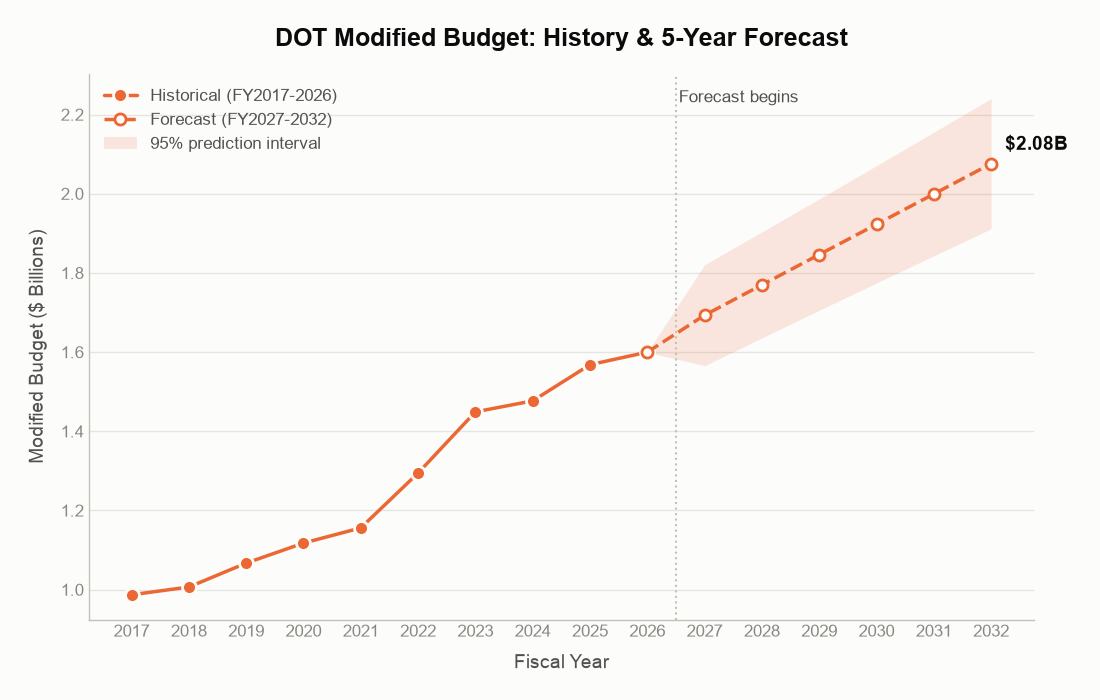

In [19]:
# Clean base style (falls back gracefully if a given seaborn style name
# isn't available in this matplotlib version).
for _style in ["seaborn-v0_8-whitegrid", "seaborn-whitegrid"]:
    if _style in plt.style.available:
        plt.style.use(_style)
        break
else:
    plt.style.use("default")

MODIFIED_COLOR = SERIES["modified"]  # validated categorical slot 2: orange
last_hist_year = int(train_table["fiscal_year"].max())
last_hist_value = train_table.loc[train_table["fiscal_year"] == last_hist_year, "modified"].iloc[0]
fc_mod = extended_fits["modified"]["forecast"].set_index("fiscal_year")

forecast_x = [last_hist_year] + EXTENDED_YEARS_PLOT
forecast_point = [last_hist_value] + list(fc_mod.loc[EXTENDED_YEARS_PLOT, "point_forecast"])
forecast_low = [last_hist_value] + list(fc_mod.loc[EXTENDED_YEARS_PLOT, "lower_95"])
forecast_high = [last_hist_value] + list(fc_mod.loc[EXTENDED_YEARS_PLOT, "upper_95"])

fig1, ax1 = plt.subplots(figsize=(11, 7), facecolor=SURFACE)
ax1.set_facecolor(SURFACE)

# Historical: solid + markers
ax1.plot(
    train_table["fiscal_year"], train_table["modified"] / 1e9,
    color=MODIFIED_COLOR, linewidth=2.5, marker="o", markersize=10,
    markerfacecolor=MODIFIED_COLOR, markeredgecolor=SURFACE, markeredgewidth=2,
    label="Historical (FY2017-2026)", zorder=3,
)

# Forecast: dashed, anchored at the last historical point so it connects
# with no visual gap
ax1.plot(
    forecast_x, np.array(forecast_point) / 1e9,
    color=MODIFIED_COLOR, linewidth=2.5, linestyle="--", marker="o", markersize=8,
    markerfacecolor=SURFACE, markeredgecolor=MODIFIED_COLOR, markeredgewidth=2,
    label="Forecast (FY2027-2032)", zorder=3,
)

# ONE shaded 95% prediction interval band, forecast portion only
ax1.fill_between(
    forecast_x, np.array(forecast_low) / 1e9, np.array(forecast_high) / 1e9,
    color=MODIFIED_COLOR, alpha=0.15, linewidth=0, zorder=1,
    label="95% prediction interval",
)

# Divider marking where the forecast starts
ax1.axvline(last_hist_year + 0.5, color=BASELINE, linewidth=1.5, linestyle=":", zorder=2)
ax1.text(
    last_hist_year + 0.55, 0.97, "Forecast begins",
    transform=ax1.get_xaxis_transform(),
    color=INK_SECONDARY, fontsize=12, va="top", ha="left",
)

# Annotate the FY2032 endpoint with its value
final_year = 2032
final_value_billions = fc_mod.loc[final_year, "point_forecast"] / 1e9
ax1.annotate(
    f"${final_value_billions:.2f}B",
    xy=(final_year, final_value_billions),
    xytext=(10, 10), textcoords="offset points",
    fontsize=14, fontweight="bold", color=INK_PRIMARY,
)

ax1.set_xlabel("Fiscal Year", fontsize=14, color=INK_SECONDARY, labelpad=10)
ax1.set_ylabel("Modified Budget ($ Billions)", fontsize=14, color=INK_SECONDARY, labelpad=10)
ax1.set_title(
    "DOT Modified Budget: History & 5-Year Forecast",
    fontsize=18, fontweight="bold", color=INK_PRIMARY, pad=20,
)
ax1.set_xticks(list(train_table["fiscal_year"]) + EXTENDED_YEARS_PLOT)
ax1.tick_params(labelsize=12, colors=INK_MUTED)

# Minimal gridlines: faint horizontal only
ax1.grid(axis="y", color=GRIDLINE, linewidth=1, alpha=0.8)
ax1.grid(axis="x", visible=False)
ax1.set_axisbelow(True)
for spine_name in ("top", "right"):
    ax1.spines[spine_name].set_visible(False)
for spine_name in ("left", "bottom"):
    ax1.spines[spine_name].set_color(BASELINE)

ax1.legend(fontsize=12, frameon=False, loc="upper left", labelcolor=INK_SECONDARY)

fig1.tight_layout(pad=2)

MODIFIED_CLEAN_PATH = "dot_forecast_modified_clean.png"
fig1.savefig(MODIFIED_CLEAN_PATH, dpi=150, facecolor=SURFACE)
print(f"Saved Figure 1 (Modified budget focus) to {MODIFIED_CLEAN_PATH}")
plt.show()


Saved Figure 2 (all three series, no bands) to dot_forecast_three_clean.png


<cell>:57: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


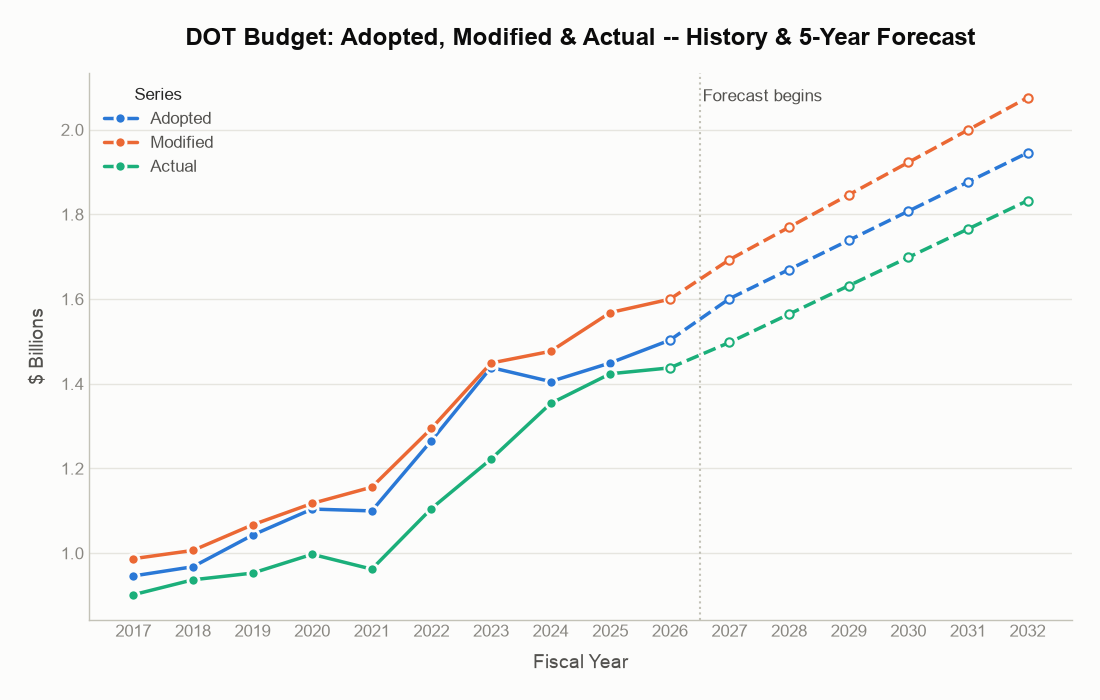

In [20]:
fig2, ax2 = plt.subplots(figsize=(11, 7), facecolor=SURFACE)
ax2.set_facecolor(SURFACE)

for col, color in SERIES.items():
    # Historical: solid + markers
    ax2.plot(
        train_table["fiscal_year"], train_table[col] / 1e9,
        color=color, linewidth=2.5, marker="o", markersize=8,
        markerfacecolor=color, markeredgecolor=SURFACE, markeredgewidth=2,
        label=col.capitalize(), zorder=3,
    )

    # Forecast: dashed, same continuity anchor as Figure 1, no shaded band
    fc = extended_fits[col]["forecast"].set_index("fiscal_year")
    last_hist_value_c = train_table.loc[train_table["fiscal_year"] == last_hist_year, col].iloc[0]
    fx = [last_hist_year] + EXTENDED_YEARS_PLOT
    fy = [last_hist_value_c] + list(fc.loc[EXTENDED_YEARS_PLOT, "point_forecast"])
    ax2.plot(
        fx, np.array(fy) / 1e9,
        color=color, linewidth=2.5, linestyle="--", marker="o", markersize=6,
        markerfacecolor=SURFACE, markeredgecolor=color, markeredgewidth=1.5,
        zorder=3,
    )

# Same forecast divider as Figure 1
ax2.axvline(last_hist_year + 0.5, color=BASELINE, linewidth=1.5, linestyle=":", zorder=2)
ax2.text(
    last_hist_year + 0.55, 0.97, "Forecast begins",
    transform=ax2.get_xaxis_transform(),
    color=INK_SECONDARY, fontsize=12, va="top", ha="left",
)

ax2.set_xlabel("Fiscal Year", fontsize=14, color=INK_SECONDARY, labelpad=10)
ax2.set_ylabel("$ Billions", fontsize=14, color=INK_SECONDARY, labelpad=10)
ax2.set_title(
    "DOT Budget: Adopted, Modified & Actual -- History & 5-Year Forecast",
    fontsize=17, fontweight="bold", color=INK_PRIMARY, pad=20,
)
ax2.set_xticks(list(train_table["fiscal_year"]) + EXTENDED_YEARS_PLOT)
ax2.tick_params(labelsize=12, colors=INK_MUTED)

ax2.grid(axis="y", color=GRIDLINE, linewidth=1, alpha=0.8)
ax2.grid(axis="x", visible=False)
ax2.set_axisbelow(True)
for spine_name in ("top", "right"):
    ax2.spines[spine_name].set_visible(False)
for spine_name in ("left", "bottom"):
    ax2.spines[spine_name].set_color(BASELINE)

ax2.legend(fontsize=12, frameon=False, loc="upper left", labelcolor=INK_SECONDARY, title="Series", title_fontsize=12)

fig2.tight_layout(pad=2)

THREE_CLEAN_PATH = "dot_forecast_three_clean.png"
fig2.savefig(THREE_CLEAN_PATH, dpi=150, facecolor=SURFACE)
print(f"Saved Figure 2 (all three series, no bands) to {THREE_CLEAN_PATH}")
plt.show()


## Cumulative 5-Year Need (Modified, FY2028-2032)

Sum of the FY2028-2032 Modified point forecasts, with a combined low/high
range built by summing the yearly lower and upper bounds. **Caveat, stated
plainly:** summing each year's independent 95% bound this way is a simple,
transparent approximation, not a statistically tight combined interval --
because all five years' forecasts come from the same fitted line, their
errors are correlated (a high FY2028 tends to come with a high FY2029,
etc.), so a rigorous joint interval would likely be narrower than this sum.
Summing the bounds is the conservative, wider direction, which is the safer
side to be wrong on for a planning range.

In [21]:
modified_forecast = extended_fits["modified"]["forecast"].set_index("fiscal_year")
five_year_window = modified_forecast.loc[list(range(2028, 2033))]

cumulative_point = five_year_window["point_forecast"].sum()
cumulative_low = five_year_window["lower_95"].sum()
cumulative_high = five_year_window["upper_95"].sum()

print("FY2028-2032 Modified forecast, year by year:")
print(five_year_window[["point_forecast", "lower_95", "upper_95"]].to_string())
print()
print("Cumulative 5-year projected budget need (Modified, FY2028-2032):")
print(f"  Point estimate : {cumulative_point:>18,.0f}")
print(f"  Low (sum of lower_95)  : {cumulative_low:>18,.0f}")
print(f"  High (sum of upper_95) : {cumulative_high:>18,.0f}")
print(f"  Range width             : {cumulative_high - cumulative_low:>18,.0f}")


FY2028-2032 Modified forecast, year by year:
              point_forecast         lower_95         upper_95
fiscal_year                                                   
2028        1,769,704,643.16 1,635,890,771.12 1,903,518,515.19
2029        1,846,236,752.18 1,705,556,225.84 1,986,917,278.52
2030        1,922,768,861.21 1,774,629,959.89 2,070,907,762.52
2031        1,999,300,970.23 1,843,196,764.26 2,155,405,176.20
2032        2,075,833,079.25 1,911,330,259.79 2,240,335,898.72

Cumulative 5-year projected budget need (Modified, FY2028-2032):
  Point estimate :      9,613,844,306
  Low (sum of lower_95)  :      8,870,603,981
  High (sum of upper_95) :     10,357,084,631
  Range width             :      1,486,480,650


## Limitation: This Is a Scenario, Not a Prediction

A 5-year projection built from 10 annual observations is an **"if current
trends continue" scenario**, not a precise prediction of what FY2028-2032
will actually look like -- stated plainly, not as a hedge:

- **The intervals widen year over year because the uncertainty is real and
  compounding.** Each additional forecast year is extrapolated further from
  the data the model actually saw, and the classic prediction-interval
  formula used throughout this notebook (Step 3) correctly grows the margin
  for that -- by FY2032 the interval is meaningfully wider than FY2027's,
  and that widening is the model being honest about what it doesn't know,
  not a defect to fix.
- **The model has no mechanism for recessions, policy shifts, or
  emergencies.** It is a straight line fit to 10 points of steady historical
  growth. It cannot see a citywide fiscal crisis, a change in how DOT's
  capital program is funded, a new mandate, or an infrastructure emergency
  coming -- any of which could move the actual FY2028-2032 numbers well
  outside even the widest interval shown here.
- **The 5-year cumulative total compounds this further.** It's five
  correlated single-year uncertainties added together, not five independent
  ones -- treat the cumulative low/high above as a wide planning range, not
  a budget figure to commit to.
- **How to use this:** the point forecasts and the cumulative total are a
  reasonable planning anchor for "what does continuing the current trend
  imply." The intervals are the range worth holding flexibility for. Neither
  is a substitute for revisiting the forecast as each actual fiscal year's
  numbers come in.

---
**Stopping here per instructions.** The FY2028-2032 year-by-year forecast
table with 95% prediction intervals, the interval-width growth, the 5-year
cumulative Modified need, and the saved plot are all above.

---
# Backtest Visualization: Predicted vs. Actual (FY2025-2027)

A visual complement to the standalone `dot_forecast_model.py` script's
backtest -- same split, **train on FY2017-2024 only** (8 annual
observations), **forecast FY2025, FY2026, and FY2027**. This is a
stricter holdout than the "Backtest" section above (which trained through
FY2025): three full unseen years instead of two, using the exact same
`fit_and_forecast()` function already defined and validated earlier in
this notebook.

**Fair comparison years: FY2025 and FY2026** -- both are complete fiscal
years with real, comparable full-year figures. **FY2027 Actual is
excluded from the "fair" charts below and marked wherever it does
appear** -- it's the same partial-year figure flagged throughout this
notebook (a few weeks elapsed as of this analysis), not a fair test of
the model.

In [22]:
viz_train = full_table[full_table["fiscal_year"] <= 2024].reset_index(drop=True)
VIZ_FORECAST_YEARS = [2025, 2026, 2027]
FAIR_YEARS = [2025, 2026]

viz_fits = {col: fit_and_forecast(viz_train, col, VIZ_FORECAST_YEARS) for col in SERIES_COLS}

viz_rows = []
for col in SERIES_COLS:
    fc = viz_fits[col]["forecast"].set_index("fiscal_year")
    for year in VIZ_FORECAST_YEARS:
        predicted = fc.loc[year, "point_forecast"]
        lower = fc.loc[year, "lower_95"]
        upper = fc.loc[year, "upper_95"]
        real = full_table.loc[full_table["fiscal_year"] == year, col].iloc[0]
        pct_error = (predicted - real) / real * 100
        viz_rows.append({
            "series": col, "fiscal_year": year, "predicted": predicted, "actual": real,
            "pct_error": pct_error, "lower_95": lower, "upper_95": upper,
            "fair": year in FAIR_YEARS,
        })

viz_table = pd.DataFrame(viz_rows)
print(f"Training window: FY2017-2024 ({len(viz_train)} observations)")
print(f"Forecast years: {VIZ_FORECAST_YEARS}  |  Fair comparison years: {FAIR_YEARS}\n")
print(viz_table.to_string(index=False))

fair_viz = viz_table[viz_table["fair"]]
mean_fair_error = fair_viz["pct_error"].abs().mean()
print(f"\nMean |% error| on fair years (FY2025-2026, all 3 series): {mean_fair_error:.2f}%")


Training window: FY2017-2024 (8 observations)
Forecast years: [2025, 2026, 2027]  |  Fair comparison years: [2025, 2026]

  series  fiscal_year        predicted           actual  pct_error         lower_95         upper_95  fair
 adopted         2025 1,492,633,763.46 1,449,323,202.00       2.99 1,309,704,347.28 1,675,563,179.65  True
 adopted         2026 1,566,808,658.35 1,503,042,033.00       4.24 1,370,796,724.61 1,762,820,592.08  True
 adopted         2027 1,640,983,553.23 1,636,737,065.00       0.26 1,430,342,421.45 1,851,624,685.01 False
modified         2025 1,535,085,759.32 1,568,194,105.00      -2.11 1,376,934,482.47 1,693,237,036.17  True
modified         2026 1,610,814,090.39 1,599,799,084.00       0.69 1,441,352,348.02 1,780,275,832.76  True
modified         2027 1,686,542,421.46 1,639,747,168.00       2.85 1,504,433,033.90 1,868,651,809.02 False
  actual         2025 1,322,421,674.04 1,423,722,022.97      -7.12 1,103,389,220.91 1,541,454,127.18  True
  actual         2026 

## Option A: Predicted vs. Actual -- Grouped Bars

Saved Option A (grouped bars) to dot_backtest_accuracy.png


<cell>:75: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


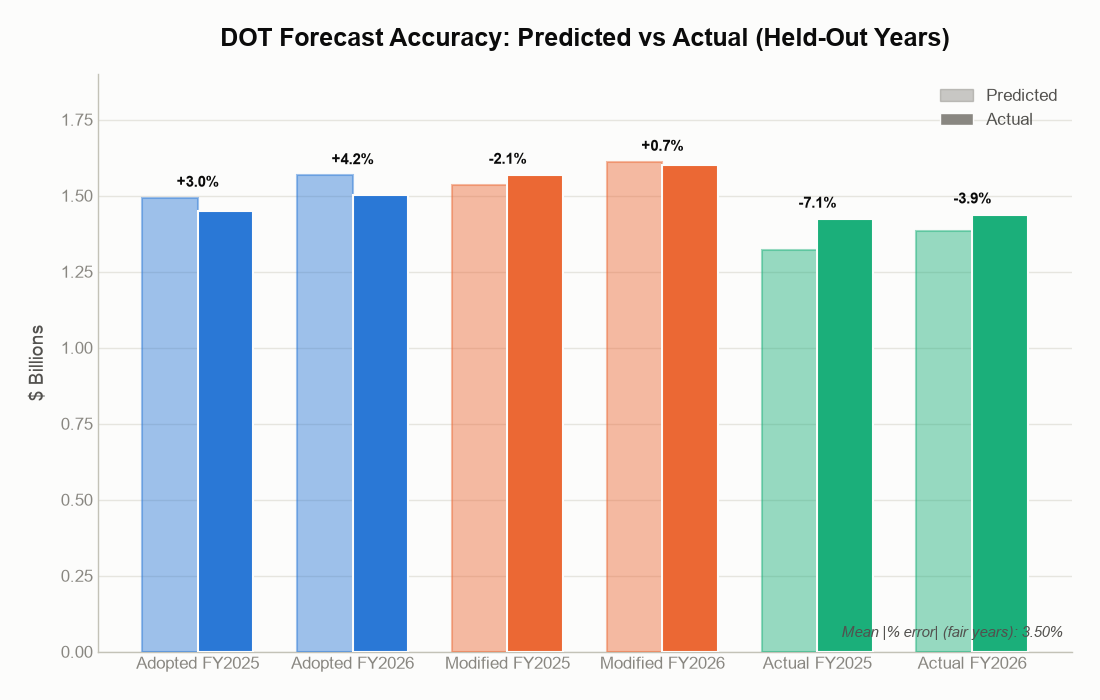

In [23]:
from matplotlib.patches import Patch

fig, ax = plt.subplots(figsize=(11, 7), facecolor=SURFACE)
ax.set_facecolor(SURFACE)

bar_data = viz_table[viz_table["fair"]].copy()
bar_data["group"] = bar_data["series"].str.capitalize() + " FY" + bar_data["fiscal_year"].astype(str)
group_order = [f"{s.capitalize()} FY{y}" for s in SERIES_COLS for y in FAIR_YEARS]
bar_data = bar_data.set_index("group").loc[group_order].reset_index()

x = np.arange(len(group_order))
width = 0.36

predicted_vals = bar_data["predicted"].values / 1e9
actual_vals = bar_data["actual"].values / 1e9
bar_colors = [SERIES[s] for s in bar_data["series"]]

bars_pred = ax.bar(
    x - width / 2, predicted_vals, width, color=bar_colors, alpha=0.45,
    edgecolor=[SERIES[s] for s in bar_data["series"]], linewidth=1.5,
    label="Predicted", zorder=3,
)
bars_act = ax.bar(
    x + width / 2, actual_vals, width, color=bar_colors, alpha=1.0,
    edgecolor=SURFACE, linewidth=1.5,
    label="Actual", zorder=3,
)

# % error label centered above each pair
for i, row in bar_data.iterrows():
    pair_top = max(predicted_vals[i], actual_vals[i])
    ax.annotate(
        f"{row['pct_error']:+.1f}%",
        xy=(x[i], pair_top), xytext=(0, 8), textcoords="offset points",
        ha="center", fontsize=11, fontweight="bold", color=INK_PRIMARY,
    )

ax.set_ylim(0, max(predicted_vals.max(), actual_vals.max()) * 1.18)
ax.set_xticks(x)
ax.set_xticklabels(group_order, fontsize=12)
ax.set_ylabel("$ Billions", fontsize=14, color=INK_SECONDARY, labelpad=10)
ax.set_title(
    "DOT Forecast Accuracy: Predicted vs Actual (Held-Out Years)",
    fontsize=18, fontweight="bold", color=INK_PRIMARY, pad=20,
)

ax.grid(axis="y", color=GRIDLINE, linewidth=1, alpha=0.8)
ax.grid(axis="x", visible=False)
ax.set_axisbelow(True)
for spine_name in ("top", "right"):
    ax.spines[spine_name].set_visible(False)
for spine_name in ("left", "bottom"):
    ax.spines[spine_name].set_color(BASELINE)
ax.tick_params(labelsize=12, colors=INK_MUTED)

# Custom legend: Predicted (light) vs Actual (solid), in neutral ink rather
# than a specific series color, since color here encodes series not P/A.
legend_handles = [
    Patch(facecolor=INK_MUTED, alpha=0.45, edgecolor=INK_MUTED, label="Predicted"),
    Patch(facecolor=INK_MUTED, alpha=1.0, edgecolor=SURFACE, label="Actual"),
]
ax.legend(handles=legend_handles, fontsize=12, frameon=False, loc="upper right", labelcolor=INK_SECONDARY)

ax.text(
    0.99, 0.02, f"Mean |% error| (fair years): {mean_fair_error:.2f}%",
    transform=ax.transAxes, ha="right", va="bottom",
    fontsize=11, color=INK_SECONDARY, style="italic",
)

fig.tight_layout(pad=2)

ACCURACY_BARS_PATH = "dot_backtest_accuracy.png"
fig.savefig(ACCURACY_BARS_PATH, dpi=150, facecolor=SURFACE)
print(f"Saved Option A (grouped bars) to {ACCURACY_BARS_PATH}")
plt.show()


## Option B: Forecast-on-Trend with Held-Out Points

Saved Option B (trend + held-out points) to dot_backtest_trend_validation.png


<cell>:89: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


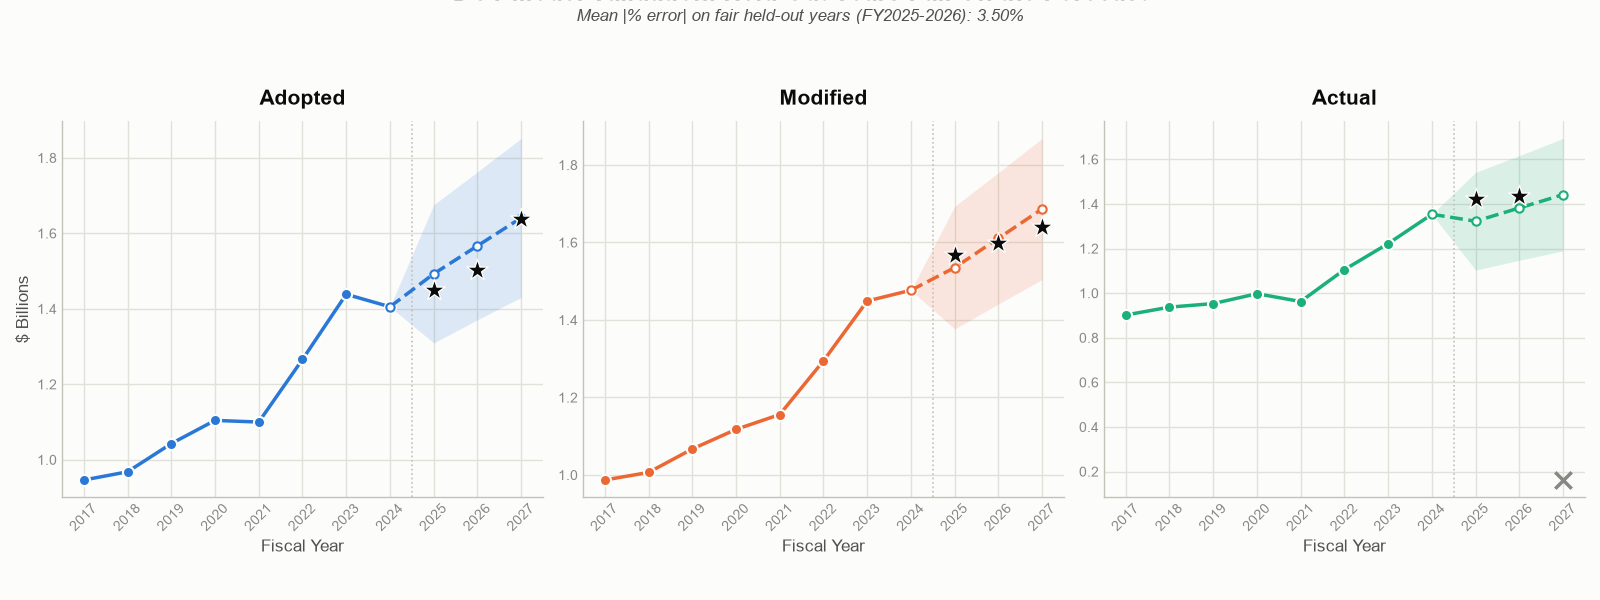

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6), facecolor=SURFACE, sharex=False)

for ax, col in zip(axes, SERIES_COLS):
    ax.set_facecolor(SURFACE)
    color = SERIES[col]

    # Training history (FY2017-2024), solid + markers
    ax.plot(
        viz_train["fiscal_year"], viz_train[col] / 1e9,
        color=color, linewidth=2.5, marker="o", markersize=8,
        markerfacecolor=color, markeredgecolor=SURFACE, markeredgewidth=1.5,
        label="Training (2017-2024)", zorder=3,
    )

    # Fitted trend + 95% PI, extended through the fair years + FY2027 (marked)
    fc = viz_fits[col]["forecast"].set_index("fiscal_year")
    last_hist_year = int(viz_train["fiscal_year"].max())
    last_hist_val = viz_train.loc[viz_train["fiscal_year"] == last_hist_year, col].iloc[0]
    fx = [last_hist_year] + VIZ_FORECAST_YEARS
    fpoint = [last_hist_val] + list(fc.loc[VIZ_FORECAST_YEARS, "point_forecast"])
    flow = [last_hist_val] + list(fc.loc[VIZ_FORECAST_YEARS, "lower_95"])
    fhigh = [last_hist_val] + list(fc.loc[VIZ_FORECAST_YEARS, "upper_95"])

    ax.plot(
        fx, np.array(fpoint) / 1e9, color=color, linewidth=2.5, linestyle="--",
        marker="o", markersize=6, markerfacecolor=SURFACE, markeredgecolor=color,
        markeredgewidth=1.5, label="Forecast trend", zorder=3,
    )
    ax.fill_between(
        fx, np.array(flow) / 1e9, np.array(fhigh) / 1e9,
        color=color, alpha=0.15, linewidth=0, label="95% interval", zorder=1,
    )

    # Real held-out points on top: fair years as stars, FY2027 marked "excluded"
    fair_real = full_table[full_table["fiscal_year"].isin(FAIR_YEARS)]
    ax.scatter(
        fair_real["fiscal_year"], fair_real[col] / 1e9,
        color=INK_PRIMARY, marker="*", s=260, zorder=5,
        edgecolor=SURFACE, linewidth=1, label="Real (held out)",
    )
    fy2027_real = full_table.loc[full_table["fiscal_year"] == 2027, col].iloc[0]
    if col == "actual":
        ax.scatter(
            [2027], [fy2027_real / 1e9], color=INK_MUTED, marker="x", s=140,
            zorder=5, linewidth=2.5, label="FY2027 (partial year, excluded)",
        )
    else:
        ax.scatter(
            [2027], [fy2027_real / 1e9], color=INK_PRIMARY, marker="*", s=260,
            zorder=5, edgecolor=SURFACE, linewidth=1,
        )

    ax.axvline(last_hist_year + 0.5, color=BASELINE, linewidth=1.2, linestyle=":", zorder=2)

    ax.set_title(col.capitalize(), fontsize=15, fontweight="bold", color=INK_PRIMARY, pad=12)
    ax.set_xlabel("Fiscal Year", fontsize=12, color=INK_SECONDARY)
    ax.set_xticks(list(viz_train["fiscal_year"]) + VIZ_FORECAST_YEARS)
    ax.tick_params(axis="x", labelrotation=45, labelsize=10, colors=INK_MUTED)
    ax.tick_params(axis="y", labelsize=10, colors=INK_MUTED)
    ax.grid(True, color=GRIDLINE, linewidth=1)
    ax.set_axisbelow(True)
    for spine_name in ("top", "right"):
        ax.spines[spine_name].set_visible(False)
    for spine_name in ("left", "bottom"):
        ax.spines[spine_name].set_color(BASELINE)

axes[0].set_ylabel("$ Billions", fontsize=12, color=INK_SECONDARY)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels, loc="lower center", ncol=5, frameon=False,
    fontsize=10.5, labelcolor=INK_SECONDARY, bbox_to_anchor=(0.5, -0.06),
)

fig.suptitle(
    "DOT Model Validation: Held-Out Years Fall On the Forecast",
    fontsize=18, fontweight="bold", color=INK_PRIMARY, y=1.03,
)
fig.text(
    0.5, 0.965, f"Mean |% error| on fair held-out years (FY2025-2026): {mean_fair_error:.2f}%",
    ha="center", fontsize=12, color=INK_SECONDARY, style="italic",
)

fig.tight_layout(rect=[0, 0.05, 1, 0.94])

TREND_VALIDATION_PATH = "dot_backtest_trend_validation.png"
fig.savefig(TREND_VALIDATION_PATH, dpi=150, facecolor=SURFACE, bbox_inches="tight")
print(f"Saved Option B (trend + held-out points) to {TREND_VALIDATION_PATH}")
plt.show()


**Both saved:** `dot_backtest_accuracy.png` (Option A, grouped bars) and
`dot_backtest_trend_validation.png` (Option B, trend + held-out points).
Option A reads faster for "how close was each number" at a glance; Option
B reads better for "does the real data actually fall on the line the
model drew" -- both are built from the identical FY2017-2024 train /
FY2025-2027 holdout, so they tell the same underlying story two different
ways.